## Data verzamelen
We genereren een dataset met prijzen van een GPU die in waarde afneemt over tijd. De prijs van de GPU neemt snel af met een bepaald percentage per maand. We nemen aan dat de prijs van de GPU in het begin $10000$ euro is. We berekenen de prijs van de GPU over een periode van 100 maanden. 

In [107]:
import numpy as np
from scipy.optimize import minimize

np.random.seed(1234)
n = 100
phi_geheim = 0.99
sigma_geheim = 200.0
y = np.zeros(n)
y[0] = 10000
for t in range(1, n):
    y[t] = phi_geheim * y[t-1] + np.random.normal(0, sigma_geheim)

## Visualiseer de data

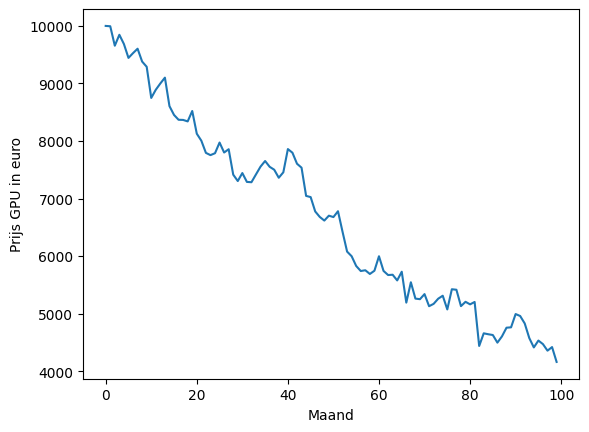

In [108]:
import matplotlib.pyplot as plt
plt.plot(y)
plt.ylabel("Prijs GPU in euro")
plt.xlabel("Maand")
plt.show()

## Train een AR(1) model

We passen MLE toe om de parameters van het AR(1) model te schatten. Je hoeft alleen de methode `negative_log_likelihood` te implementeren. 

In [ ]:
def negative_log_likelihood(params, y):
    # Antwoord: 
    ...
    return ...

result = minimize(negative_log_likelihood, [0.5, 1.0], args=(y,), bounds=[(-1, 1), (1e-3, None)])

print(f"Geschatte phi {result.x[0]:.3f} lijkt op de echte phi {phi_geheim:.3f}")
print(f"Geschatte sigma {result.x[1]:.1f} is ongeveer de echte sigma {sigma_geheim:.1f}")

Geschatte phi 0.991 lijkt op de echte phi 0.990
Geschatte sigma 199.9 is ongeveer de echte sigma 200.0


## Genereer voorspellingen
Geneer voorspellingen voor de prijs van de GPU over een periode van nog eens 100 maanden. De eerste 100 maanden zijn dus de maanden waarvoor we de data hebben (het model getraind hebben) en de volgende 100 maanden zijn de maanden waarvoor we voorspellingen genereren. 

Definieer een variabele `y2` van lengte 100 waarvoor de eerste waarde van `y2` gebaseerd is op de laatste waarde van `y` en de voorspelling van de AR(1) model. 

In [ ]:
# Antwoord: 
...
y2 = ...

## Visualiseer de data

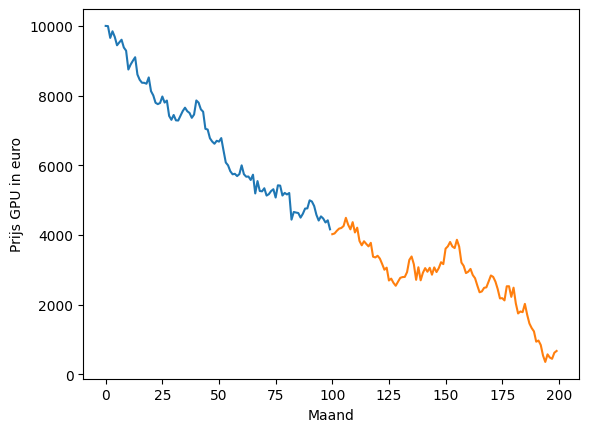

In [111]:
import matplotlib.pyplot as plt
plt.plot(y)
plt.plot(range(n, n + len(y2)), y2)
plt.ylabel("Prijs GPU in euro")
plt.xlabel("Maand")
plt.show()